In [1]:
from google.colab import files
uploaded = files.upload()

Saving final_dataset.csv to final_dataset.csv


In [2]:
import pandas as pd

df = pd.read_csv("final_dataset.csv")
df.head()

,user_id,product,price,platform,category,income,expense,label
0,1,Rice,60,Amazon,Food,15000,200,Affordable
1,2,Shoes,2000,Flipkart,Fashion,20000,1800,Not Affordable
2,3,Milk,50,Local,Food,12000,100,Affordable
3,4,Phone,15000,Amazon,Electronics,25000,14000,Not Affordable
4,5,Laptop,55000,Flipkart,Electronics,40000,30000,Not Affordable


MSE: 0.4717528012409082
Logistic: 0.0
Decision Tree: 1.0
Random Forest: 0.5


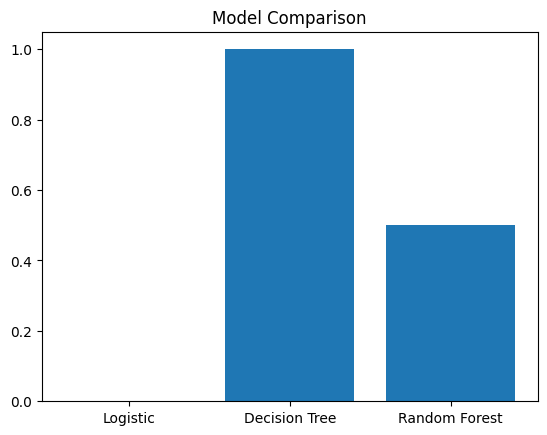

In [3]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Convert label
df['label'] = df['label'].map({'Affordable': 1, 'Not Affordable': 0})

# Convert categorical
df = pd.get_dummies(df, columns=['product', 'platform', 'category'], drop_first=True)

X = df.drop(['label'], axis=1)
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Models
lr = LinearRegression()
lr.fit(X_train, y_train)
mse = mean_squared_error(y_test, lr.predict(X_test))

log = LogisticRegression(max_iter=1000)
log.fit(X_train, y_train)
acc_log = accuracy_score(y_test, log.predict(X_test))

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
acc_dt = accuracy_score(y_test, dt.predict(X_test))

rf = RandomForestClassifier()
rf.fit(X_train, y_train)
acc_rf = accuracy_score(y_test, rf.predict(X_test))

print("MSE:", mse)
print("Logistic:", acc_log)
print("Decision Tree:", acc_dt)
print("Random Forest:", acc_rf)

# Graph
models = ['Logistic', 'Decision Tree', 'Random Forest']
acc = [acc_log, acc_dt, acc_rf]

plt.figure()
plt.bar(models, acc)
plt.title("Model Comparison")
plt.show()